# Building an epigenetic methylation clock with scikit-learn

Reference articles:
- Horvath, Genome Biology 2013: https://genomebiology.biomedcentral.com/articles/10.1186/gb-2013-14-10-r115#MOESM21
- Varshavsky et al. Cell Reports Methods 2023: https://www.cell.com/cell-reports-methods/fulltext/S2667-2375(23)00211-4


# Data loading & inspection

In [1]:
local = True

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

if local:
    folder = 'data/'
else:
    folder = "/content/drive/MyDrive/University/Computation Biology/Ex1 Data"
datasets = [ x for x in os.listdir(folder) if x.endswith('.csv') and x.startswith('GSE')]

tables = []

for dataset in datasets:
    name = dataset.split('.')[0]
    table = pd.read_csv(os.path.join(folder,dataset),index_col=0).transpose()
    table['Source'] = name
    print(dataset,table.shape)
    tables.append(table)

full_table = pd.concat(tables,axis=0,join='outer')


methylation_site_names = [x for x in full_table.columns if x not in ['age','Source']]

if os.path.exists(os.path.join(folder, 'site_annotations.csv')):
    methylation_site_annotations = pd.read_csv(os.path.join(folder, 'site_annotations.csv'),index_col=0)
else:
    methylation_site_annotations = pd.read_csv('humanmethylation450_15017482_v1-2.csv',skiprows=7,index_col='IlmnID')
    methylation_site_annotations = methylation_site_annotations.loc[methylation_site_names][['CHR','MAPINFO','Strand','SourceSeq','UCSC_RefGene_Name']]
    methylation_site_annotations.to_csv(os.path.join(folder, 'site_annotations.csv'))


GSE72680.csv (422, 1048)
GSE157131.csv (1218, 2280)
GSE55763.csv (2639, 2376)
GSE154566.csv (235, 936)
GSE69270.csv (184, 981)
GSE147221.csv (679, 2376)
GSE73103.csv (355, 979)
GSE64495.csv (113, 2376)
GSE40279.csv (656, 2376)
GSE42861.csv (689, 2376)
GSE87648.csv (382, 2351)
GSE36054.csv (134, 2376)
GSE41169.csv (95, 2376)
GSE72775.csv (335, 2376)
GSE51032.csv (845, 2376)
GSE105018.csv (1658, 1026)
GSE103657.csv (586, 995)
GSE84727.csv (665, 1027)
GSE30870.csv (20, 2376)


## Inspecting the dataset

Pay attention that for some individuals, not all methylation levels were measured.

In [3]:
full_table.head()

,age,cg00058879,cg00059225,cg00080081,cg00094518,cg00101260,cg00103778,cg00129827,cg00144180,cg00145253,...,ch.5.432310R,ch.5.79606571R,ch.6.2925136R,ch.6.41978480R,ch.7.135065R,ch.7.2635062R,ch.7.2986028F,ch.7.3189261R,ch.8.103893680R,ch.9.1059422R
GSM1868353,70.0,0.252,0.521,0.065,0.211,0.205,0.246,0.108,0.944,0.310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868174,22.0,0.215,0.417,0.155,0.069,0.245,0.385,0.243,0.797,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868180,21.0,0.046,0.326,0.183,0.022,0.319,0.267,0.211,0.833,0.210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1868183,43.0,0.137,0.433,0.103,0.092,0.291,0.331,0.208,0.901,0.285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM1946528,44.0,0.160,0.463,0.130,0.118,0.279,0.267,0.207,0.830,0.280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(full_table.shape)

(11910, 2376)


## Inspecting the metadata for each methylation site.
- IlmnID: Name.
- CHR: Chromosome.
- MAPINFO: start position along the reference genome.
- STRAND: on which strand is the CpG site located.
- Source: The corresponding DNA fragment

In [5]:
methylation_site_annotations.head()

,CHR,MAPINFO,Strand,SourceSeq,UCSC_RefGene_Name
IlmnID,,,,,
cg00058879,22.0,40082173.0,F,GGGCGGCCAGGCTGCTGGTGCTGCTGAACTTCCTGGCGGGCGTGAG...,CACNA1I;CACNA1I
cg00059225,5.0,151304357.0,F,GCAGGGAGCCAACAGACACGCTGGAGTTTAACAAACAGCAATACTC...,GLRA1;GLRA1;GLRA1;GLRA1
cg00080081,17.0,33701776.0,F,CGCACGTTTGTTAAAATGAGGTCATAATGTTCATGCTGTTTCATAA...,SLFN11;SLFN11;SLFN11;SLFN11;SLFN11
cg00094518,7.0,130418549.0,F,TCTGGGCGGACTTGCGCGGCAGCTCTGGCGAGGGCTCCTGGGAGAA...,KLF14
cg00101260,17.0,53426657.0,R,CGGTTCCAATGAAGCGTGGAGCATCTGTGATTCCAATCCTGAGGGG...,NaN


In [6]:
methylation_site_annotations.tail()

,CHR,MAPINFO,Strand,SourceSeq,UCSC_RefGene_Name
IlmnID,,,,,
ch.7.2635062R,7.0,127719998.0,F,CAGCTCTTCCAGGGGCACTTTGGCATTGACTAGGTATCCCTGAGAA...,SND1
ch.7.2986028F,7.0,141887997.0,F,CAGACAACACAGGTCTGCTTTGGATCTGATCAGATGGACTAAATCT...,LOC100124692
ch.7.3189261R,7.0,151489100.0,F,CAGGACATGCTTGCTACTGTCTGATTCTCTGGCATTGGGCAAATGA...,PRKAG2;PRKAG2
ch.8.103893680R,8.0,103824504.0,F,CAGCAGTCAGCTTTGAAGGAGCAAAACATGGTGCTACAGAACATGT...,NaN
ch.9.1059422R,9.0,83693653.0,F,CAGCAGCAGACCACAACAGCTGAGAACTTGGCTGTTGAAGTCAAAC...,NaN


# Part I: Exploratory Data Analysis

1.	For each CpG site, calculate the Spearman correlation coefficient between its methylation level and the age of the donor. Display the result as a histogram and comment on the findings.


In [7]:
print(full_table['age'].isna().any())

False


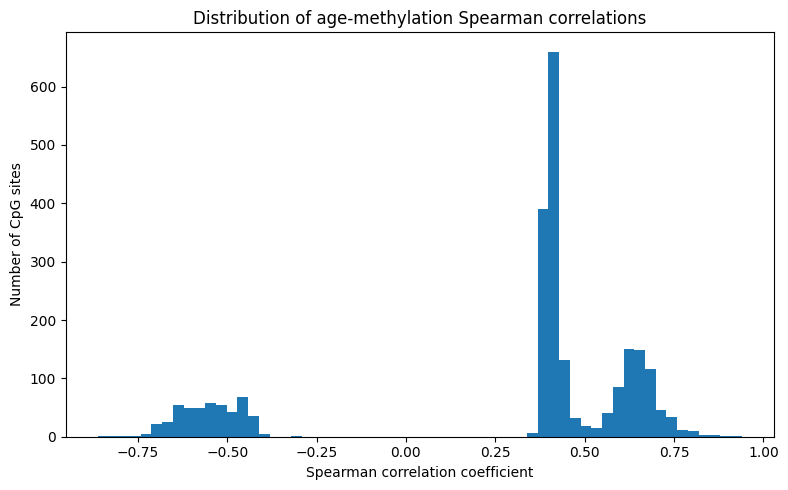

In [8]:
corrs = full_table[methylation_site_names].corrwith(full_table["age"], method="spearman").dropna()

plt.figure(figsize=(8, 5))
plt.hist(corrs, bins=60)
plt.xlabel("Spearman correlation coefficient")
plt.ylabel("Number of CpG sites")
plt.title("Distribution of age-methylation Spearman correlations")
plt.tight_layout()
plt.show()

The results are not surprising - as the hw mentioned, this is a dataset already limited:
"The 450K sites were already trimmed down to ~2375 CpG sites that are correlated with aging"

This shows in the data - all the cpg sites are correlative to some degree, and there is a hole from -0.25 to 0.25.

On top of that, we can also see that some sites are correlated positively and some negatively, suggesting that methylation in some sites causes/is caused by aging, and for other methylation is removed in the same condition, which means we should be careful in further analysis to not assume aging->increased methylation for every site.

2.	For the 5 CpG sites with highest and lowest Spearman correlation coefficient values, visualize the relationship between methylation level and age using a scatter plot. Comment on the findings.



In [9]:
print(corrs)

cg00058879         0.622965
cg00059225         0.756109
cg00080081        -0.516912
cg00094518         0.713521
cg00101260        -0.581767
                     ...   
ch.7.2635062R     -0.446936
ch.7.2986028F     -0.454754
ch.7.3189261R     -0.461569
ch.8.103893680R   -0.448639
ch.9.1059422R     -0.437972
Length: 2374, dtype: float64


In [10]:
selected_sites= list(corrs.nsmallest(5).index) + list(corrs.nlargest(5).index)
print(selected_sites)

['cg19283806', 'cg26685941', 'cg08128734', 'cg05412028', 'cg00573770', 'cg16867657', 'cg22454769', 'cg06639320', 'cg21572722', 'cg04875128']


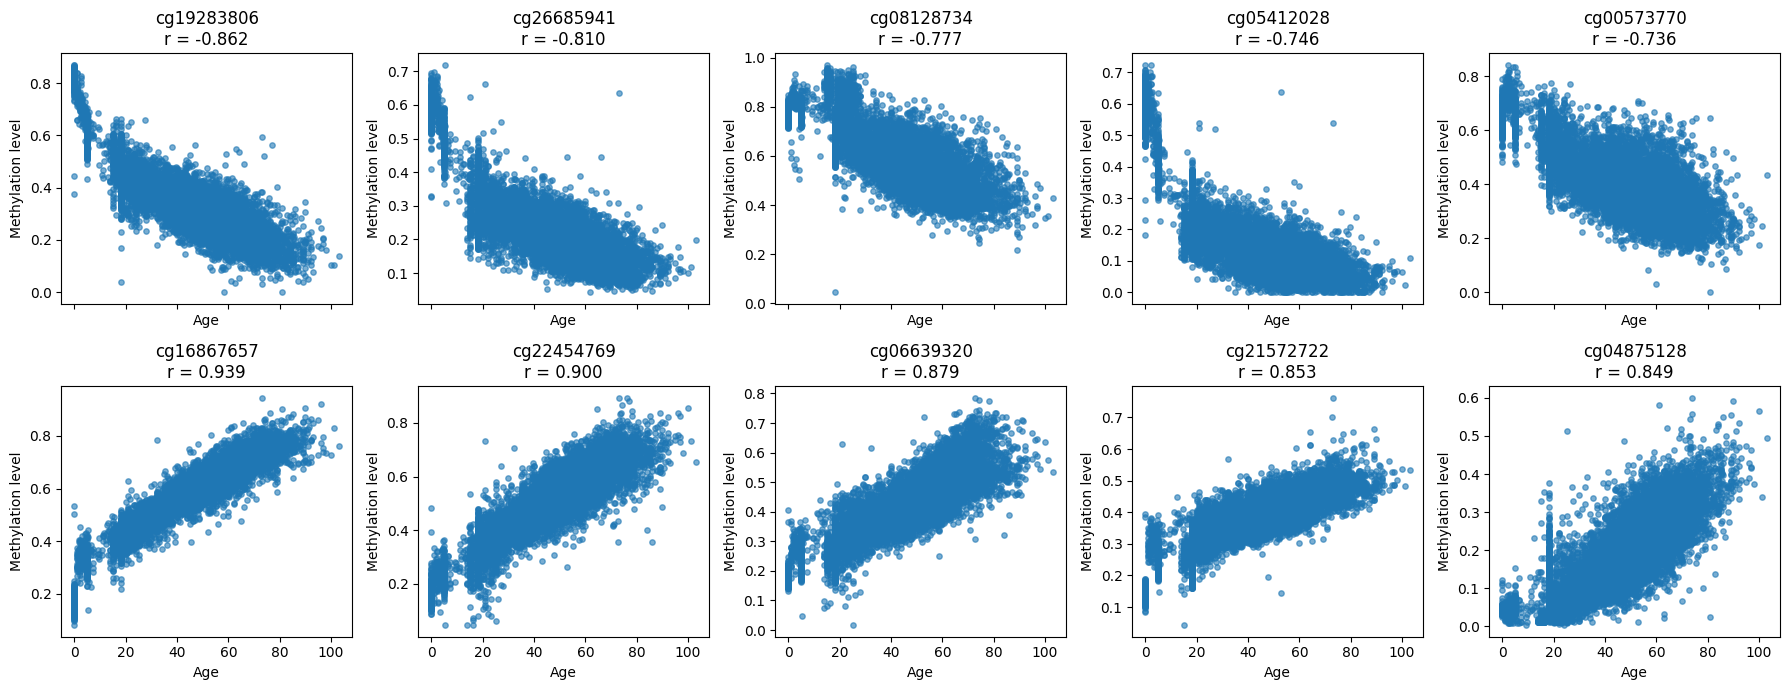

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
axes = axes.flatten()

for ax, site in zip(axes, selected_sites):
    plot_df = full_table[["age", site]].dropna()

    ax.scatter(plot_df["age"], plot_df[site], alpha=0.6, s=15)
    ax.set_title(f"{site}\nr = {corrs[site]:.3f}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Methylation level")

plt.tight_layout()
plt.show()

The plots seem pretty standard - very straightforward increase for the positives and decrese for the negatives.

The only thing that is somewhat unusual is the straight lines that are in the start or middle left of the plots, which we assume could be due to some ages being very popular in the study/the sequencing machine varying strongly for weak signals

3.	Select all sites located along Chromosome 10 and reorder them by their location along the genome. Calculate the matrix of Spearman correlation coefficients between all pairs of methylation levels and visualize as a heatmap. Comment on the findings.


In [12]:
chr10_sites = methylation_site_annotations[methylation_site_annotations["CHR"] == 10].sort_values("MAPINFO").index

chr10_sites = [site for site in chr10_sites if site in methylation_site_names]

chr10_methylation = full_table[chr10_sites]

chr10_corr_matrix = chr10_methylation.corr(method="spearman")

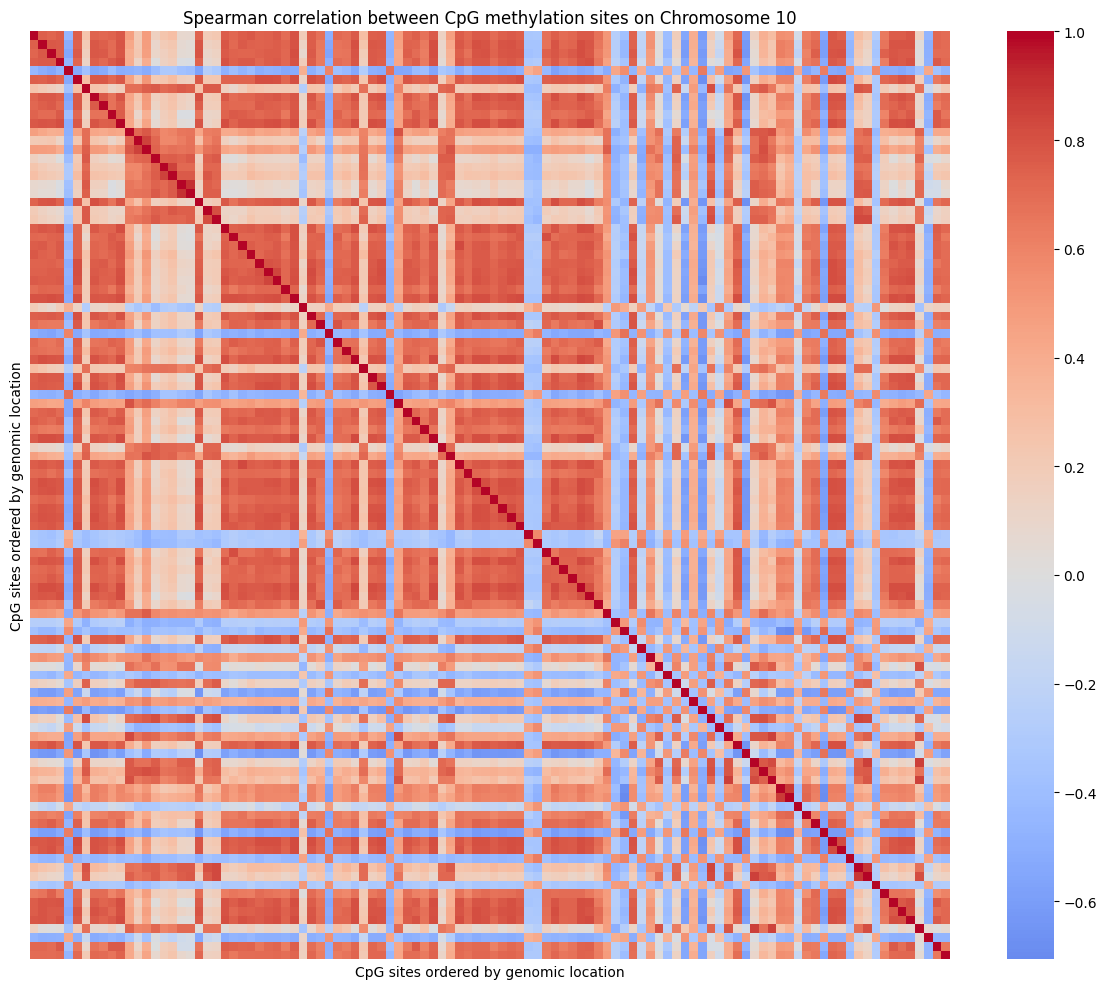

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    chr10_corr_matrix,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)
plt.title("Spearman correlation between CpG methylation sites on Chromosome 10")
plt.xlabel("CpG sites ordered by genomic location")
plt.ylabel("CpG sites ordered by genomic location")
plt.tight_layout()
plt.show()

The findings are rather interesting. The heatmap creates square shapes which means that many areas are closely connected within themselves, and very weakly correalated with areas between these squares. this could be due to spacial correlation - if one site in an area is methylated, so do those around it

# Part II: Data Partition

Here, we perform the data partition, splitting the dataset into a training and a test set. We then split the training set into five folds for cross-validation purpose.

- The dataset was compiled from 19 separate studies. To account for potential "batch effects" (i.e., distribution shift from one study to the other), we use one of the study as test set.

- For the cross-validation, we use a stratified K-fold approach.

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
X , Y = full_table[methylation_site_names], full_table['age']
study = full_table['Source'] # The study chosen from.

test_set = (study == 'GSE84727')

X_train, Y_train = X[~test_set], Y[~test_set]
X_test, Y_test = X[test_set], Y[test_set]


Y_train_binned = KBinsDiscretizer(n_bins=20,encode='ordinal').fit_transform(Y_train.to_numpy()[:,None])[:,0]
skf = StratifiedKFold(n_splits=5,random_state=0,shuffle=True)
skf.get_n_splits(X_train,Y_train_binned)

/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/almogtavor/Documents/code/un/computational-biology/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


5

4.	Report the number of samples per study and visualize the age distribution for each of the 19 studies, using a boxplot. Comment on the findings.



,Study,Number of samples
0,GSE103657,586
1,GSE105018,1658
2,GSE147221,679
3,GSE154566,235
4,GSE157131,1218
5,GSE30870,20
6,GSE36054,134
7,GSE40279,656
8,GSE41169,95
9,GSE42861,689


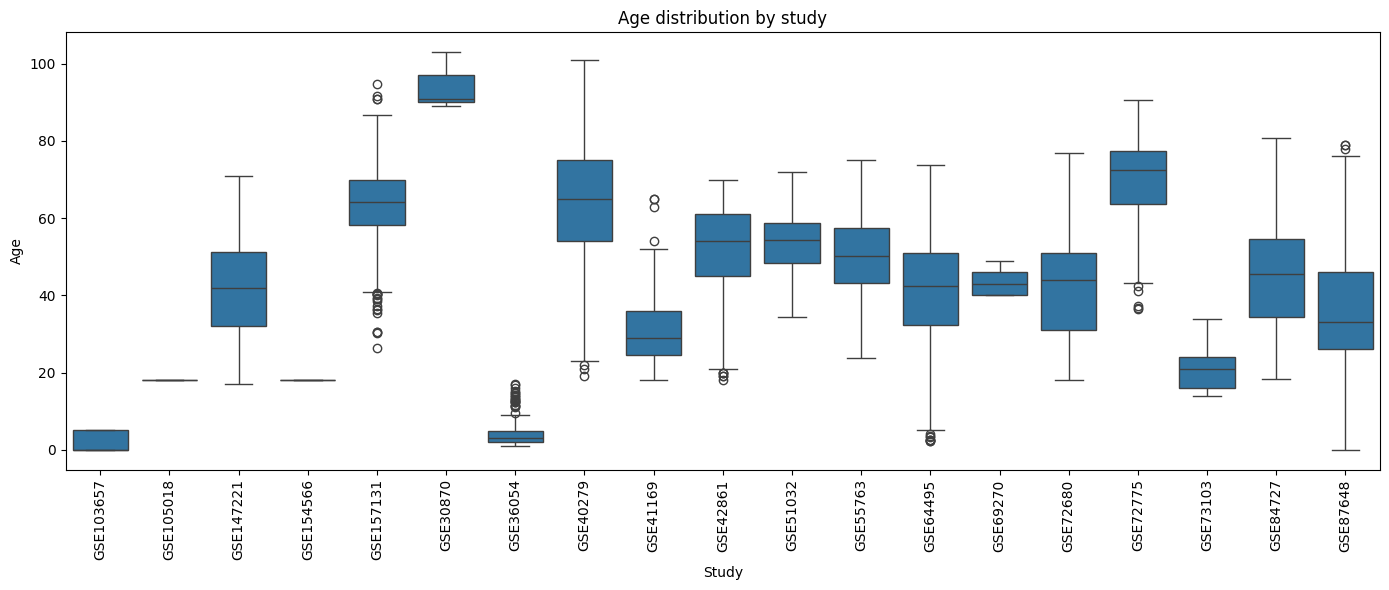

In [15]:
study_age_df = full_table[["Source", "age"]].dropna()

sample_counts = (
    study_age_df["Source"]
    .value_counts()
    .sort_index()
    .rename_axis("Study")
    .reset_index(name="Number of samples")
)

display(sample_counts)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=study_age_df,
    x="Source",
    y="age",
    order=sample_counts["Study"]
)
plt.xticks(rotation=90)
plt.xlabel("Study")
plt.ylabel("Age")
plt.title("Age distribution by study")
plt.tight_layout()
plt.show()

It seems that while most studies have focused on a wide variety of ages around 40 to 80, some studies have in particular focused on young/old poplulations.

We should be careful when predicting for those since they can behave differently/be affected by different biology.

It should also be noted that the whiskers of the studies' ages is quite big, and that some studies have many outliers.

5.	Read how the partition between train and test was done on the notebook.
a.	Why did we use dataset “GSE84727” as a test set rather than by using a random split?  
b.	Why did we use a stratified split for the training set rather than a random split or a grouped split?


a. We use this dataset because it is diverse and stable - it has no severe outliers, and its median age is quite close to the median of all the studies. it has an "avverage" population

b. Using a stratified split was important to keep the age distribution in the validation set consistant and balanced. We wanted to avoid a case in which the validation set accidentally contains for example only young patients, which might have different biology than older ones - a case which would make our model fail on them/not study properly.

# Part III: Training and evaluating a linear model

Build a scikit-learn Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	Ridge Regression.
For each of the following values of K: [5,10,20,30,50,100,500,1000], select the optimal L2 regularization strength over the range by cross-validation.

6.	Report the performance of the model on the test set as a table with error bars (defined as the standard deviation of the absolute error, divided by the square root of the test set size).
How does the performance evolve with K?


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

k_values = [5, 10, 20, 30, 50, 100, 500, 1000]
alpha_values = np.logspace(-2, 6, 17)

In [17]:
cv_splits = list(skf.split(X_train, Y_train_binned))
results = []
best_models = {}

In [18]:
for k in k_values:
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("selector", SelectKBest(score_func=f_regression, k=k)), ("model", Ridge())])

    grid = GridSearchCV(estimator=pipe, param_grid={"model_alpha": alpha_values}, scoring="neg_mean_absolute_error", cv=cv_splits)

    grid.fit(X_train, Y_train)

    y_pred = grid.predict(X_test)
    abs_errors = np.abs(Y_test - y_pred)

    # mae= mean absolute errorr
    test_mae = mean_absolute_error(Y_test, y_pred)
    test_error_bar = abs_errors.std(ddof=1) / np.sqrt(len(abs_errors))

    results.append({"K": k, "best_alpha": grid.best_params_["model_alpha"], "cv_mae": -grid.best_score_,"test_mae": test_mae, "test_error_bar": test_error_bar})

    best_models[k] = grid.best_estimator_

ValueError: Invalid parameter 'model_alpha' for estimator Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('selector',
                 SelectKBest(k=5,
                             score_func=<function f_regression at 0x1168b1da0>)),
                ('model', Ridge())]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

In [ ]:
results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    results_df["K"],
    results_df["test_mae"],
    yerr=results_df["test_error_bar"],
    marker="o",
    capsize=4
)
plt.xscale("log")
plt.xlabel("Number of selected CpG sites, K")
plt.ylabel("Test MAE")
plt.title("Test-set performance as a function of K")
plt.tight_layout()
plt.show()

It seems the model gets better as k goes up, since the error rate drops.

It should also be important to note that as k goes up, so does the optimal alpha, which makes sense - more paramaters requires harsher regularization

7.	For K=50, plot the feature importance of the selected sites.
Are some chromosomes over-represented among these sites?

8.	For each of the five folds, the selected sites may be different. How many sites are found in all five folds? In at least 2 folds? Discuss the findings.

# Part IV: Automated feature selection by LASSO
Replace the previous Pipeline by a Pipeline consisting of:
-	An imputer for missing values (SimpleImputer)
-	LASSO Regression.

9.	For various values of the L1 regularization strength, fit a model (on the full training set) and calculate the performance on the test set as well as the number of CpG sites with non-zero coefficients. Plot the test set performance as function of the number of sites for both models.

Why would feature selection with LASSO outperform feature selection by Pearson correlation? Conversely, why would Ridge outperform LASSO? Suggest a “best-of-both worlds” solution.



10.	Why would feature selection with LASSO outperform feature selection by Pearson correlation? Conversely, why would Ridge outperform LASSO? Suggest a “best-of-both worlds” solution.

# Part V: Experimenting with the loss function.

Since our target metric is the MAE rather than the mean square error, we might get better results by using it as a training loss function. This is implemented in two scikit-learn classes:
(1)	QuantileRegression (with quantile=0.5) and L1 regularization. Exact, but slow optimization by linear programming.
(2)	SGDRegression (with loss=’huber’,epsilon=1e-2) and L1/L2 regularization. Faster, approximate optimization by stochastic gradient descent. Pay attention that the learning rate needs to be adjusted.

11.	Repeat question 6. with the MAE loss rather than Ridge regression and compare the findings.



# Part VI: Training a Generalized Additive Model (GAM)

The exploratory data analysis showed a non-linear relationship between methylation level and age, suggesting that a GAM model may be more appropriate. To this end, build a Pipeline consisting of the following steps:
-	An imputer for missing values (SimpleImputer)
-	Top-K feature selection using the F-statistics of the correlation coefficient (functions: SelectKBest and f_regression).
-	SplineTransformer using cubic splines, uniformly spaced knots, linear extrapolation.
-	Ridge regression.


12.	For each of the following values of K: [5,10,20,30,50], select the optimal regularization strength and number of knots, and report the performance over the test set. Compare the results with the ones of Part III.

13.	Plot the feature effect functions using the Partial Dependency plot function of scikit-learn. Conclude on the benefits of using trainable non-linearities.



14.	Do you expect that performance could be improved by instead implementing the GAM with boosted trees of depth 1?

# Part VII: Glass-box vs Black-Box models.

15.	Similarly train and evaluate a “black-box” Random Forest regressor on the same dataset. How does the performance compare with the one of the “glass-box” models? Conclude on the merits of each method.

## Bonus
Suggest and implement another approach to further improve the performance of the age predictor.